In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier #Multi layer Perceptron

In [156]:
data = pd.read_csv("./pandas/titanic.csv")
data.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [157]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [158]:
data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

In [159]:
labelEncoder_gender = LabelEncoder()

In [160]:
data["gender_numeric"] = labelEncoder_gender.fit_transform(data["Sex"])

In [161]:
selected_columns = ['Survived', 'Pclass', 'Name', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare', 'gender_numeric']

In [162]:
dati_puliti = data[selected_columns]
dati_puliti

,Survived,Pclass,Name,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,gender_numeric
0,0,3,Mr. Owen Harris Braund,22.0,1,0,7.2500,1
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,38.0,1,0,71.2833,0
2,1,3,Miss. Laina Heikkinen,26.0,0,0,7.9250,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,35.0,1,0,53.1000,0
4,0,3,Mr. William Henry Allen,35.0,0,0,8.0500,1
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,27.0,0,0,13.0000,1
883,1,1,Miss. Margaret Edith Graham,19.0,0,0,30.0000,0
884,0,3,Miss. Catherine Helen Johnston,7.0,1,2,23.4500,0
885,1,1,Mr. Karl Howell Behr,26.0,0,0,30.0000,1


In [163]:
dati_puliti.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Age                      887 non-null    float64
 4   Siblings/Spouses Aboard  887 non-null    int64  
 5   Parents/Children Aboard  887 non-null    int64  
 6   Fare                     887 non-null    float64
 7   gender_numeric           887 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 55.6+ KB


In [164]:
features = ['Pclass', 'Age', 'Fare', 'gender_numeric', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard']
output = ['Survived']
selected_data = data[features+output]
selected_data.head()

X = selected_data[features].to_numpy()
y = selected_data[output].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

In [165]:
#Come calcolare max_depth ottimale!
lista_profondita = list(range(1, 15))
#lista_profondita
lista_score_test=[]
lista_score_training=[]
for profondita in lista_profondita:
    #addestriamo un random forest con profondità del for
    rf = RandomForestClassifier(max_depth=profondita, n_estimators=100)
    rf.fit(X_train, y_train.reshape(-1))
    lista_score_test.append(rf.score(X_test, y_test))
    lista_score_training.append(rf.score(X_train, y_train))

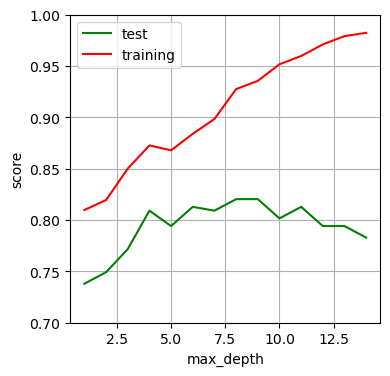

In [166]:
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(lista_profondita, lista_score_test, color="green", label="test")
ax.plot(lista_profondita, lista_score_training, color="red", label="training")
ax.set_xlabel("max_depth")
ax.set_ylabel("score")
ax.grid()
ax.set_ylim(0.7, 1)
ax.legend()
plt.show()

In [167]:
#Come calcolare numeri di alberi
lista_n_alberi = list(range(1, 100))
#lista_profondita
lista_score_test=[]
lista_score_training=[]
for albero in lista_n_alberi:
    #addestriamo un random forest con profondità del for
    rf = RandomForestClassifier(max_depth=7, n_estimators=albero)
    rf.fit(X_train, y_train.reshape(-1))
    lista_score_test.append(rf.score(X_test, y_test))
    lista_score_training.append(rf.score(X_train, y_train))

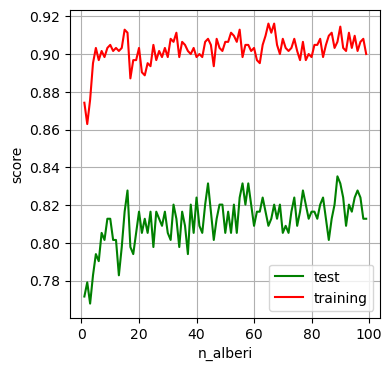

In [168]:
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(lista_n_alberi, lista_score_test, color="green", label="test")
ax.plot(lista_n_alberi, lista_score_training, color="red", label="training")
ax.set_xlabel("n_alberi")
ax.set_ylabel("score")
ax.grid()
#ax.set_ylim(0.7, 1)
ax.legend()
plt.show()

## Foresta con max_depth e n_alberi ottimale

#### I due valori:

max_depth = 7, n_esitmators = 40

In [169]:
rf = RandomForestClassifier(max_depth=7, n_estimators=40)
rf.fit(X_train, y_train.reshape(-1))

,n_estimators,40
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [170]:
rf.score(X_test, y_test)

0.8089887640449438

In [171]:
for feature, importance in zip(features, rf.feature_importances_):
    print(f'{feature} : {importance:.3f}')

Pclass : 0.148
Age : 0.177
Fare : 0.178
gender_numeric : 0.416
Siblings/Spouses Aboard : 0.047
Parents/Children Aboard : 0.034


In [172]:
features = ['Pclass', 'Age', 'Fare', 'gender_numeric']
output = ['Survived']
selected_data = data[features+output]
selected_data.head()

X = selected_data[features].to_numpy()
y = selected_data[output].to_numpy()

In [173]:
scaler = StandardScaler()
#Mi normalizza tutto!
X_norm = scaler.fit_transform(X)

In [174]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, random_state=42, test_size=0.3)

In [190]:
neural_network = MLPClassifier(hidden_layer_sizes = (4, 3), max_iter = 1000)

In [191]:
neural_network.fit(X_train, y_train.reshape(-1))

,hidden_layer_sizes,"(4, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,None


In [192]:
neural_network.score(X_test, y_test) #Ha il 100% dell'accuratezza

0.7715355805243446